In [4]:
import os
from getpass import getpass
from urllib.parse import quote

REPO_URL = "https://github.com/williamsnunezp/prediccion-atenciones-medicas-salud.git"
REPO_DIR = "/content/prediccion-atenciones-medicas-salud"

token = os.getenv("GITHUB_TOKEN")
if token is None:
    token = getpass("GitHub token (deja vacío si el repo es público o ya fue cargado): ").strip()

if token:
    token = quote(token, safe="")
    clone_url = REPO_URL.replace("https://", f"https://{token}@")
else:
    clone_url = REPO_URL

cloned = False
if not os.path.exists(REPO_DIR):
    !git clone {clone_url} {REPO_DIR}
    cloned = True
else:
    print("Ya existe:", REPO_DIR)

print(os.listdir(REPO_DIR))

if cloned:
    print('Preparando entorno...')
    !mkdir -p /etc/OpenCL/vendors && echo "libnvidia-opencl.so.1" > /etc/OpenCL/vendors/nvidia.icd
    %pip install -q optuna optuna_integration


GitHub token (deja vacío si el repo es público o ya fue cargado): ··········
Cloning into '/content/prediccion-atenciones-medicas-salud'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 59 (delta 0), reused 0 (delta 0), pack-reused 49 (from 1)
Receiving objects: 100% (59/59), 16.14 MiB | 9.39 MiB/s, done.
Resolving deltas: 100% (2/2), done.
['.git', 'requirements.txt', '.gitignore', 'README.md', '.vscode', 'notebooks', 'data', 'articles']
Preparando entorno...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 25.2 MB/s eta 0:00:00


# **Fase 4: Modelado - Comparación de modelos con balanceo de clases**

### Arquitectura del pipeline

```
Dataset (412,579 registros, 10 features)
    │
    ├── Para cada seed en [42, 123]:
    │       │
    │       ├── train_test_split (85%/15%, stratify, seed=N) → TRAIN / TEST
    │       │
    │       ├── train_test_split (85%/15% de TRAIN, stratify, seed=N) → TR_VAL / TST_VAL
    │       │
    │       ├── TR_VAL ──► Preprocesar → Balanceo (4 técnicas)
    │       │       │
    │       │       └── Optuna (12 trials, MedianPruner) en TST_VAL como validación
    │       │
    │       ├── Reentrenar con mejores params en TRAIN completo balanceado
    │       │
    │       └── TEST (15%) → Evaluar SIN balanceo
    │
    └── Agregar resultados de ambos seeds → mean ± std global
```

### Componentes clave

| Componente | Configuración |
|------------|---------------|
| **Modelos** | XGBoost, LightGBM (API nativa, GPU CUDA) |
| **Balanceo** | SMOTETomek (SMOTETK), RepeatedEditedNearestNeighbours (REENN), NeighbourhoodCleaningRule (NC), InstanceHardnessThreshold (IHT) |
| **Optimización** | Optuna (TPE Sampler, MedianPruner, 12 trials por combinación) |
| **Métrica objetivo** | Recall (maximize) en Optuna, pruning con auc (proxy) |
| **Preprocesamiento** | MinMaxScaler (numéricas) + OrdinalEncoder (categóricas) |
| **Semillas** | [42, 123] (2 seeds) |
| **Folds validacion por seed** | 1 fold manual (train_test_split)  |
| **Total balanced datasets** | 8 (2 seeds × 4 técnicas × 1 fold) |
| **Hold-out** | 15% estratificado por semilla |


In [38]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import NeighbourhoodCleaningRule, RepeatedEditedNearestNeighbours, InstanceHardnessThreshold
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score, log_loss, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler

import xgboost as xgb
import lightgbm as lgb
import optuna
from optuna_integration import LightGBMPruningCallback, XGBoostPruningCallback

warnings.filterwarnings("ignore")

In [6]:
ruta_csv_x = os.path.join(REPO_DIR, "data", "factures.csv")
ruta_csv_y = os.path.join(REPO_DIR, "data", "target.csv")

tipos_x = {
    "especialidad": "category",
    "citas_previas": "category",
    "mes_cita": "category",
    "presencial_remoto": "category",
    "edad": "float32",
    "dia_mes_cita": "category",
    "tasa_noshow_previa": "category",
    "seguro": "category",
    "diferencia_dias": "float32",
    "noshow_previos": "category"
}
tipos_y = {
    "atendido": "int"
}

df_x = pd.read_csv(ruta_csv_x,dtype=tipos_x, delimiter=";")
df_y = pd.read_csv(ruta_csv_y, dtype=tipos_y)

df_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412579 entries, 0 to 412578
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   especialidad        412579 non-null  category
 1   citas_previas       412579 non-null  category
 2   mes_cita            412579 non-null  category
 3   presencial_remoto   412579 non-null  category
 4   edad                412579 non-null  float32 
 5   dia_mes_cita        412579 non-null  category
 6   tasa_noshow_previa  412579 non-null  category
 7   seguro              412579 non-null  category
 8   diferencia_dias     412579 non-null  float32 
 9   noshow_previos      412579 non-null  category
dtypes: category(8), float32(2)
memory usage: 6.7 MB


In [39]:
fixed_params = {
    'XGB': {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'device': 'cuda',
        'max_bin': 64,
    },
    'LGBM': {
        'objective': 'binary',
        'device': 'gpu',
        'metric': 'auc',
        'gpu_platform_id': 0,
        'gpu_device_id': 0,
        'min_child_weight': 1e-3,
        'max_bin': 64,
        'verbosity': -1,
    }
}

smote_dict = {
    "IHT": lambda rs: InstanceHardnessThreshold(estimator=HistGradientBoostingClassifier(max_iter=80, max_depth=8, min_samples_leaf=20, random_state=rs),
                                                cv=4, sampling_strategy="majority", random_state=rs, n_jobs=-1),
    "NC": lambda rs: NeighbourhoodCleaningRule(sampling_strategy="majority", n_neighbors=10, n_jobs=-1), # edited_nearest_neighbours=EditedNearestNeighbours(kind_sel="all", n_neighbors=5)
    "REENN": lambda rs: RepeatedEditedNearestNeighbours(sampling_strategy="majority", n_neighbors=10, max_iter=4, n_jobs=-1),
    "SMOTETK": lambda rs: SMOTETomek(sampling_strategy="minority", n_jobs=-1, random_state=rs)
}

def preprocesar(X_tr,X_vl):
    scaler = MinMaxScaler()
    X_tr_num = scaler.fit_transform(X_tr.select_dtypes(include=['float32']))
    X_vl_num = scaler.transform(X_vl.select_dtypes(include=['float32']))

    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_tr_cat = encoder.fit_transform(X_tr.select_dtypes(include=['category']))
    X_vl_cat = encoder.transform(X_vl.select_dtypes(include=['category']))

    X_tr_proc = np.hstack([X_tr_num, X_tr_cat])
    X_vl_proc = np.hstack([X_vl_num, X_vl_cat])

    return X_tr_proc, X_vl_proc

def get_param_space(nombre_modelo, trial):
    return {
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
    }

def predict_model(_modelo,data_tr_val,data_tst_val,params_nativos,num_boost_round,semilla_seleccionada, trial=None, calcular_val=True,calcular_train=False):
    params = {**fixed_params[_modelo], 'random_state': semilla_seleccionada, **params_nativos}

    if _modelo == 'XGB':
        if calcular_val and trial is not None:
            pruning_callback = XGBoostPruningCallback(trial, "valid-auc")
            modelo = xgb.train(params,  data_tr_val['df_xgb_tr'], num_boost_round=num_boost_round,
                                            evals=[(data_tst_val['df_xgb_val'], "valid")], callbacks=[pruning_callback], verbose_eval=False)
        else:
            modelo = xgb.train(params, data_tr_val['df_xgb_tr'], num_boost_round=num_boost_round)

        if calcular_train:
            y_train_prob = modelo.predict(data_tr_val['df_xgb_tr'])
            y_train_pred = (y_train_prob >= 0.5).astype(int)
        else:
            y_train_prob = None
            y_train_pred = None

        y_test_prob = modelo.predict(data_tst_val['df_xgb_val'])
        y_test_pred = (y_test_prob >= 0.5).astype(int)

    elif _modelo == 'LGBM':
        if calcular_val and trial is not None:
            pruning_callback= LightGBMPruningCallback(trial, "auc", valid_name="valid_auc")
            modelo = lgb.train(params, data_tr_val['df_lgb_tr'], num_boost_round=num_boost_round,
                                valid_sets=[data_tst_val['df_lgb_val']], valid_names=["valid_auc"], callbacks=[pruning_callback])
        else:
            modelo = lgb.train(params, data_tr_val['df_lgb_tr'], num_boost_round=num_boost_round)

        if calcular_train:
            y_train_prob = modelo.predict(data_tr_val['df_lgb_tr'].data)
            y_train_pred = (y_train_prob >= 0.5).astype(int)
        else:
            y_train_prob = None
            y_train_pred = None

        y_test_prob = modelo.predict(data_tst_val['df_lgb_val_inf'])
        y_test_pred = (y_test_prob >= 0.5).astype(int)

    return y_train_pred, y_train_prob, y_test_pred, y_test_prob

def calculate_all_metrics(y_true, y_pred, y_proba=None):
    accuracy = accuracy_score(y_true, y_pred)
    precision_1, recall_1, f1_1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', pos_label=1, zero_division=0
    )
    precision_0, recall_0, f1_0, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', pos_label=0, zero_division=0
    )
    roc_auc = roc_auc_score(y_true, y_proba) if y_proba is not None else None
    return {
        'Accuracy': accuracy,
        'Precision (1)': precision_1,
        'Recall (1)': recall_1,
        'F1 (1)': f1_1,
        'Precision (0)': precision_0,
        'Recall (0)': recall_0,
        'F1 (0)': f1_0,
        'ROC-AUC': roc_auc
    }

In [40]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

mejores_hiperparametros = {}

seeds = [42, 123]
N_TRIALS = 12

modelos_nombres = ['XGB', 'LGBM']

# ─── Busqueda de hiperparametros con Optuna ───
for nombre_smote in smote_dict.keys():
    recall_values = {m: [] for m in modelos_nombres}
    tiempos = {m: 0 for m in modelos_nombres}

    for semilla in seeds:
        # 1. Train/test split para esta semilla
        X_train, X_test, y_train, y_test = train_test_split(
            df_x, df_y, test_size=0.15, random_state=semilla, stratify=df_y
        )

        X_tr_val, X_tst_val, y_tr_val, y_tst_val = train_test_split(
            X_train, y_train, test_size=0.15, random_state=semilla, stratify=y_train
        )

        # 2. Preprocesar
        X_tr_val_proc, X_tst_val_proc = preprocesar(X_tr_val, X_tst_val)

        # 3. Balancear
        smote = smote_dict[nombre_smote](semilla)
        X_tr_val_bal, y_tr_val_bal = smote.fit_resample(X_tr_val_proc, y_tr_val)

        # 4. Crear DMatrix/Dataset
        data_tr_val = {
            'df_xgb_tr': xgb.QuantileDMatrix(X_tr_val_bal, label=y_tr_val_bal, max_bin=64),
            'df_lgb_tr': lgb.Dataset(X_tr_val_bal, label=y_tr_val_bal, free_raw_data=False),
        }
        data_tst_val = {
            'df_xgb_val': xgb.QuantileDMatrix(X_tst_val_proc, label=y_tst_val, ref=data_tr_val['df_xgb_tr'], max_bin=64),
            'df_lgb_val': lgb.Dataset(X_tst_val_proc, label=y_tst_val, reference=data_tr_val['df_lgb_tr'], free_raw_data=False),
            'df_lgb_val_inf': X_tst_val_proc,
        }

        folds = [{'data_tr_val': data_tr_val, 'data_tst_val': data_tst_val, 'y_tst_val': y_tst_val}]

        for nombre_modelo in modelos_nombres:
            t_modelo = time.time()
            # 5. Optuna
            def objective(trial, _modelo=nombre_modelo, _seed=semilla, _folds=folds):
                params = get_param_space(_modelo, trial)
                num_boost_round = trial.suggest_int('num_boost_round', 400, 1200)
                params_nativos = params.copy()
                recall_scores = []
                for fold_data in _folds:
                    _, _, y_test_pred, _ = predict_model(
                        _modelo, fold_data['data_tr_val'], fold_data['data_tst_val'], params_nativos,
                        num_boost_round, _seed, trial=trial, calcular_val=True, calcular_train=False
                    )
                    recall = recall_score(fold_data['y_tst_val'], y_test_pred, pos_label=1)
                    recall_scores.append(recall)
                trial.set_user_attr("fold_recall", recall_scores)
                return np.mean(recall_scores)

            study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=semilla),
                pruner=optuna.pruners.MedianPruner(n_startup_trials=4, n_warmup_steps=5, interval_steps=1)
            )
            study.optimize(objective, n_trials=N_TRIALS, catch=(Exception,), show_progress_bar=False)

            best_trial = study.best_trial
            best_params = best_trial.params
            best_n_rounds = best_params.pop('num_boost_round')
            best_recall = best_trial.value

            tiempos[nombre_modelo] += time.time() - t_modelo
            recall_values[nombre_modelo].append(best_recall)

            mejores_hiperparametros.setdefault(semilla, {}).setdefault(nombre_smote, {})[nombre_modelo] = {**best_params, 'num_boost_round': best_n_rounds}

            print(
                f"{nombre_smote:8s} | {nombre_modelo:5s} | seed {semilla:<4} | "
                f"Recall={best_recall:.4f} | n_rounds={best_n_rounds} | params={best_params}"
            )

    for nombre_modelo in modelos_nombres:
        mean_recall = np.mean(recall_values[nombre_modelo])
        std_recall = np.std(recall_values[nombre_modelo])
        print(
            f"{nombre_smote:8s} | {nombre_modelo:5s} |   seeds   | "
            f"mean Recall={mean_recall:.4f} ± {std_recall:.4f}  | "
            f"Tiempo={tiempos[nombre_modelo]:.1f}s"
        )
    print()

IHT      | XGB   | seed 42   | Recall=0.8559 | n_rounds=1148 | params={'max_depth': 12, 'learning_rate': 0.09672449252922814}
IHT      | LGBM  | seed 42   | Recall=0.8498 | n_rounds=986 | params={'max_depth': 7, 'learning_rate': 0.08927180304353628}
IHT      | XGB   | seed 123  | Recall=0.8500 | n_rounds=785 | params={'max_depth': 12, 'learning_rate': 0.04839825891759375}
IHT      | LGBM  | seed 123  | Recall=0.8453 | n_rounds=889 | params={'max_depth': 11, 'learning_rate': 0.05302190470864929}
IHT      | XGB   |   seeds   | mean Recall=0.8529 ± 0.0030  | Tiempo=54.0s
IHT      | LGBM  |   seeds   | mean Recall=0.8475 ± 0.0023  | Tiempo=206.3s

NC       | XGB   | seed 42   | Recall=0.9079 | n_rounds=524 | params={'max_depth': 9, 'learning_rate': 0.014322493718230255}
NC       | LGBM  | seed 42   | Recall=0.9065 | n_rounds=1176 | params={'max_depth': 10, 'learning_rate': 0.010485387725194618}
NC       | XGB   | seed 123  | Recall=0.8990 | n_rounds=581 | params={'max_depth': 10, 'learning

# **Fase 5: Evaluación - Análisis de resultados**

### Resultados en TEST (15% hold-out, 2 seeds: 42, 123)

| Combinación | Accuracy | Precision (C1) | Recall (C1) | Precision (C0) | Recall (C0) | ROC AUC |
|-------------|----------|----------------|-------------|----------------|-------------|---------|
| **REENN + LGBM** | 0.4158 ± 0.0011 | 0.2952 ± 0.0008 | **0.9173 ± 0.0029** | 0.8944 ± 0.0035 | 0.2424 ± 0.0004 | 0.6846 ± 0.0028 |
| **REENN + XGB** | 0.4186 ± 0.0009 | 0.2961 ± 0.0003 | **0.9164 ± 0.0000** | 0.8950 ± 0.0004 | 0.2464 ± 0.0012 | 0.6877 ± 0.0035 |
| **NC + LGBM** | 0.4313 ± 0.0004 | 0.2987 ± 0.0001 | 0.9002 ± 0.0006 | 0.8863 ± 0.0003 | 0.2691 ± 0.0008 | 0.6824 ± 0.0023 |
| **NC + XGB** | 0.4357 ± 0.0020 | 0.3002 ± 0.0000 | 0.8985 ± 0.0059 | 0.8871 ± 0.0041 | 0.2757 ± 0.0047 | 0.6857 ± 0.0029 |
| **IHT + XGB** | 0.4963 ± 0.0001 | 0.3203 ± 0.0001 | 0.8556 ± 0.0004 | 0.8817 ± 0.0003 | 0.3721 ± 0.0000 | 0.6844 ± 0.0037 |
| **IHT + LGBM** | 0.4959 ± 0.0012 | 0.3193 ± 0.0007 | 0.8497 ± 0.0012 | 0.8778 ± 0.0012 | 0.3736 ± 0.0012 | 0.6875 ± 0.0013 |
| **SMOTETK + XGB** | 0.7640 ± 0.0008 | 0.5862 ± 0.0051 | 0.2775 ± 0.0031 | 0.7886 ± 0.0003 | 0.9322 ± 0.0022 | 0.7094 ± 0.0005 |
| **SMOTETK + LGBM** | 0.7586 ± 0.0037 | 0.5689 ± 0.0202 | 0.2523 ± 0.0051 | 0.7831 ± 0.0001 | 0.9337 ± 0.0068 | 0.6882 ± 0.0023 |

> C1 = Clase 1 (NO VINO / inasistencia). C0 = Clase 0 (VINO / asistencia).

### Análisis — Recall (sensibilidad) como métrica principal

**¿Por qué Recall (C1)?** En el contexto hospitalario, un falso negativo (predecir que el paciente sí asistirá cuando en realidad no asiste) tiene un costo elevado: el turno se pierde sin posibilidad de reasignación. El Recall mide qué proporción de inasistencias reales logra detectar el modelo. Priorizar Recall(C1) significa "ante la duda, marcar como no-show" para poder intervenir (recordatorios, sobrebooking, etc.).

| Combinación ganadora | Recall (C1) | Trade-off |
|----------------------|-------------|-----------|
| **REENN + LGBM** | **0.9173 ± 0.0029** | Baja accuracy (0.4158), muchas falsas alarmas (Precision C1 ~0.30) |
| **REENN + XGB** | **0.9164 ± 0.0000** | Baja accuracy (0.4186), Recall muy estable entre semillas |

> Las combinaciones con **REENN** (Repeated Edited Nearest Neighbours) lideran el ranking con ~91.7% de Recall, detectando más de 9 de cada 10 inasistencias. **NC** e **IHT** también superan el umbral del 80%. **SMOTETK** maximiza accuracy y ROC-AUC a costa de un Recall bajo (~0.25–0.28). Esto valida la estrategia de limpieza agresiva de la clase mayoritaria para maximizar la detección de no-shows.


In [41]:
filas_train = []
filas_test = []
filas_balanceo = []
predicciones = {}

for semilla in seeds:
    # 1. Train/test split para esta semilla
    X_train, X_test, y_train, y_test = train_test_split(
        df_x, df_y, test_size=0.15, random_state=semilla, stratify=df_y
    )

    # 2. Preprocesar
    X_train_proc, X_test_proc = preprocesar(X_train, X_test)

    # 3. Para cada combinación smote × modelo
    for nombre_smote, smote_factory in smote_dict.items():
        smote = smote_factory(semilla)
        X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

        n_orig = len(y_train)
        n_bal = len(y_train_bal)
        cambio_pct = ((n_bal - n_orig) / n_orig) * 100

        filas_balanceo.append({
            'Semilla': semilla,
            'Técnica': nombre_smote,
            'Original': n_orig,
            'Balanceado': n_bal,
            'Cambio%': cambio_pct
        })

        data_train = {
            'df_xgb_tr': xgb.QuantileDMatrix(X_train_bal, label=y_train_bal, max_bin=64),
            'df_lgb_tr': lgb.Dataset(X_train_bal, label=y_train_bal, free_raw_data=False),
        }
        data_test = {
            'df_xgb_val': xgb.QuantileDMatrix(X_test_proc, label=y_test, ref=data_train['df_xgb_tr'], max_bin=64),
            'df_lgb_val': lgb.Dataset(X_test_proc, label=y_test, reference=data_train['df_lgb_tr'], free_raw_data=False),
            'df_lgb_val_inf': X_test_proc,
        }

        for nombre_modelo in modelos_nombres:
            params = mejores_hiperparametros[semilla][nombre_smote][nombre_modelo]
            params_nativos = params.copy()
            n_rounds = params_nativos.pop('num_boost_round', 100)

            y_train_pred, y_train_prob, y_test_pred, y_test_prob = predict_model(nombre_modelo, data_train, data_test,
                params_nativos, n_rounds, semilla, trial=None, calcular_val=False, calcular_train=True
            )

            predicciones[f'seed{semilla}_{nombre_smote}_{nombre_modelo}'] = {
                'y_test': y_test,
                'y_pred': y_test_pred,
                'y_proba': y_test_prob
            }

            filas_train.append({
                'Semilla': semilla,
                'SMOTE': nombre_smote,
                'Modelo': nombre_modelo,
                **calculate_all_metrics(y_train_bal, y_train_pred, y_train_prob)
            })

            filas_test.append({
                'Semilla': semilla,
                'SMOTE': nombre_smote,
                'Modelo': nombre_modelo,
                **calculate_all_metrics(y_test, y_test_pred, y_test_prob)
            })

df_train = pd.DataFrame(filas_train)
df_test = pd.DataFrame(filas_test)
df_balanceo = pd.DataFrame(filas_balanceo)
df = {'Train': df_train, 'Test': df_test}

# ─── Tabla de balanceo ───
print("=" * 60)
print("  DISTRIBUCIÓN DE BALANCEO")
print("=" * 60)
display(df_balanceo)

# ─── Resultados train y test (ambas semillas) ───
for titulo, df in df.items():
    print(f"\n{'='*60}")
    print(f"  RESULTADOS {titulo.upper()} (ambas semillas)")
    print(f"{'='*60}")
    display(df.sort_values(['Semilla', 'Recall (1)'], ascending=[True, False])
            .style.highlight_max(subset=['Recall (1)', 'ROC-AUC'], color='lightcoral'))

# ─── Resultados globales (mean ± std) ───
print(f"\n{'='*60}")
print(f"  RESULTADOS GLOBALES (mean ± std)")
print(f"{'='*60}")
metric_cols = ['Accuracy', 'Precision (1)', 'Recall (1)', 'Precision (0)', 'Recall (0)', 'F1 (1)', 'F1 (0)', 'ROC-AUC']
df_global = df_test.groupby(['SMOTE', 'Modelo'])[metric_cols].agg(['mean', 'std'])
display(df_global.sort_values(('Recall (1)', 'mean'), ascending=False))


  DISTRIBUCIÓN DE BALANCEO


,Semilla,Técnica,Original,Balanceado,Cambio%
0,42,IHT,350692,180254,-48.600481
1,42,NC,350692,130723,-62.724271
2,42,REENN,350692,124033,-64.631928
3,42,SMOTETK,350692,485134,38.336204
4,123,IHT,350692,180254,-48.600481
5,123,NC,350692,131230,-62.579700
6,123,REENN,350692,124536,-64.488497
7,123,SMOTETK,350692,485326,38.390953



  RESULTADOS TRAIN (ambas semillas)


,Semilla,SMOTE,Modelo,Accuracy,Precision (1),Recall (1),F1 (1),Precision (0),Recall (0),F1 (0),ROC-AUC
0,42,IHT,XGB,0.998169,0.999944,0.996394,0.998166,0.996407,0.999945,0.998172,0.999998
4,42,REENN,XGB,0.854644,0.873116,0.935979,0.903456,0.789547,0.638442,0.705999,0.920107
2,42,NC,XGB,0.834015,0.845926,0.928334,0.885216,0.796989,0.624618,0.700354,0.901869
5,42,REENN,LGBM,0.821862,0.845796,0.923153,0.882783,0.730117,0.552616,0.629086,0.877813
3,42,NC,LGBM,0.797404,0.817653,0.908829,0.860833,0.730996,0.550030,0.627730,0.857065
6,42,SMOTETK,XGB,0.928197,0.983579,0.870935,0.923836,0.884197,0.985460,0.932086,0.987439
1,42,IHT,LGBM,0.928162,0.985164,0.869418,0.923679,0.883147,0.986907,0.932148,0.967927
7,42,SMOTETK,LGBM,0.826600,0.919182,0.716169,0.805075,0.767516,0.937032,0.843845,0.889544
8,123,IHT,XGB,0.974447,0.998973,0.949871,0.973803,0.952219,0.999024,0.975060,0.998978
12,123,REENN,XGB,0.883447,0.897364,0.947297,0.921654,0.838402,0.716208,0.772503,0.948812



  RESULTADOS TEST (ambas semillas)


,Semilla,SMOTE,Modelo,Accuracy,Precision (1),Recall (1),F1 (1),Precision (0),Recall (0),F1 (0),ROC-AUC
5,42,REENN,LGBM,0.416550,0.295711,0.919334,0.447484,0.896865,0.242638,0.381945,0.686520
4,42,REENN,XGB,0.419248,0.296324,0.916378,0.447835,0.895284,0.247292,0.387540,0.690169
2,42,NC,XGB,0.434340,0.300255,0.902672,0.450621,0.889986,0.272346,0.417065,0.687745
3,42,NC,LGBM,0.431577,0.298799,0.899780,0.448621,0.886078,0.269627,0.413446,0.684027
0,42,IHT,XGB,0.496275,0.320267,0.855329,0.466034,0.881453,0.372080,0.523275,0.681733
1,42,IHT,LGBM,0.495080,0.318833,0.848853,0.463554,0.876983,0.372711,0.523106,0.688364
6,42,SMOTETK,XGB,0.763375,0.582580,0.279660,0.377910,0.788819,0.930690,0.853902,0.708991
7,42,SMOTETK,LGBM,0.755942,0.554571,0.255894,0.350198,0.783035,0.928907,0.849756,0.686600
12,123,REENN,XGB,0.417955,0.295851,0.916441,0.447302,0.894683,0.245531,0.385318,0.685194
13,123,REENN,LGBM,0.415063,0.294614,0.915184,0.445737,0.891907,0.242073,0.380794,0.682622



  RESULTADOS GLOBALES (mean ± std)


Accuracy           Precision (1)           Recall (1)  \
                    mean       std          mean       std       mean   
SMOTE   Modelo                                                          
REENN   LGBM    0.415806  0.001051      0.295162  0.000775   0.917259   
        XGB     0.418602  0.000914      0.296088  0.000334   0.916410   
NC      LGBM    0.431262  0.000446      0.298733  0.000095   0.900189   
        XGB     0.435738  0.001977      0.300243  0.000018   0.898491   
IHT     XGB     0.496340  0.000091      0.320336  0.000096   0.855611   
        LGBM    0.495928  0.001200      0.319345  0.000723   0.849701   
SMOTETK XGB     0.763957  0.000823      0.586172  0.005080   0.277491   
        LGBM    0.758584  0.003736      0.568854  0.020199   0.252311   

                         Precision (0)           Recall (0)            \
                     std          mean       std       mean       std   
SMOTE   Modelo                                                          
REENN   LGBM    0.002934      0.894386  0.003506   0.242356  0.000400   
        XGB     0.000044      0.894983  0.000425   0.246412  0.001246   
NC      LGBM    0.000578      0.886279  0.000284   0.269062  0.000800   
        XGB     0.005913      0.887068  0.004128   0.275673  0.004706   
IHT     XGB     0.000400      0.881654  0.000285   0.372070  0.000015   
        LGBM    0.001200      0.877832  0.001201   0.373559  0.001199   
SMOTETK XGB     0.003068      0.788593  0.000320   0.932223  0.002168   
        LGBM    0.005068      0.783093  0.000082   0.933702  0.006782   

                  F1 (1)              F1 (0)             ROC-AUC            
                    mean       std      mean       std      mean       std  
SMOTE   Modelo                                                              
REENN   LGBM    0.446611  0.001235  0.381370  0.000814  0.684571  0.002756  
        XGB     0.447568  0.000377  0.386429  0.001571  0.687682  0.003517  
NC      LGBM    0.448596  0.000035  0.412802  0.000910  0.682421  0.002272  
        XGB     0.450082  0.000762  0.420610  0.005014  0.685703  0.002888  
IHT     XGB     0.466148  0.000162  0.523300  0.000035  0.684360  0.003715  
        LGBM    0.464221  0.000943  0.524092  0.001394  0.687465  0.001271  
SMOTETK XGB     0.376653  0.001777  0.854413  0.000723  0.709364  0.000528  
        LGBM    0.349457  0.001048  0.851786  0.002871  0.688194  0.002255

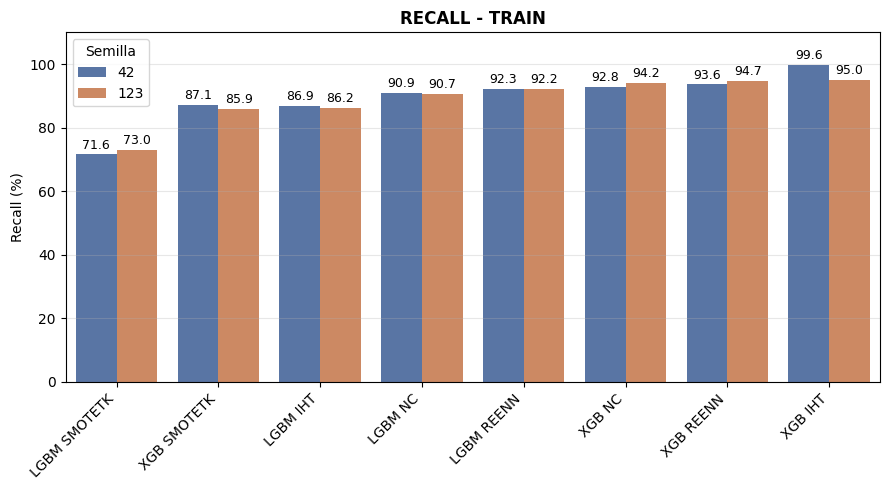

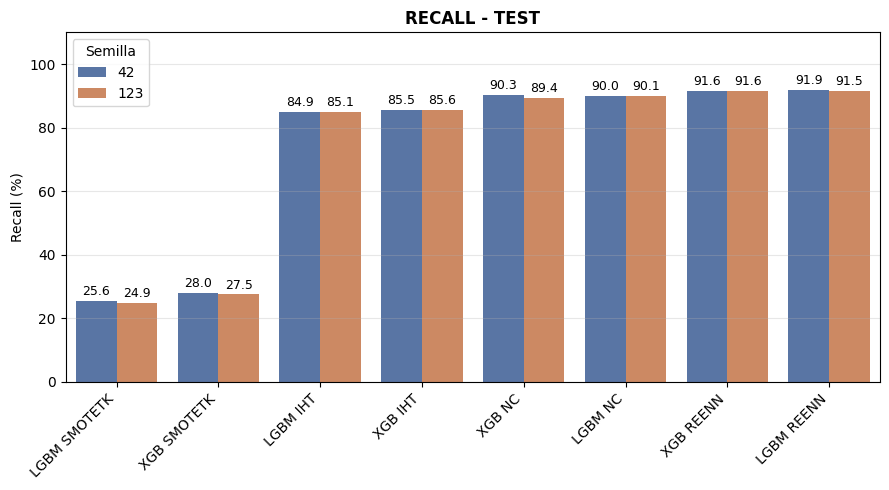

In [65]:
for titulo, df in df.items():

    df_temp = df.copy()
    df_temp['Combinacion'] = df_temp['Modelo']+ ' ' + df_temp['SMOTE']
    df_temp['Recall (%)'] = df_temp['Recall (1)'] * 100
    mean_recall = df_temp.groupby('Combinacion')['Recall (1)'].mean().sort_values().index
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=df_temp, x='Combinacion', y='Recall (%)', palette=['#4C72B0', '#DD8452'], hue='Semilla', ax=ax, order=mean_recall)
    ax.set_title(f'RECALL - {titulo.upper()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Recall (%)')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(0, 110)
    ax.grid(axis='y', alpha=0.3)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', fontsize=9, padding=2)
    #ax.legend(loc='center left', bbox_to_anchor=(-0.25, 0.5), ncol=1)
    plt.tight_layout()
    plt.show()

# **Fase 6: Implementación**

### 6.1. Objetivo
Anticipar la probabilidad de inasistencias para optimizar recursos, reducir inasistencias y mejorar la programación de citas. Se propone implementar un **ensamble orientado a maximizar el Recall de la clase 1 (inasistencias)**.

### 6.2. Modelo seleccionado — Ensamble para maximizar Recall

La combinación REENN + XGB/LGBM obtuvo el mayor Recall(C1) (~0.917), detectando el 91.7% de las inasistencias reales. Se propone un ensamble de ambos modelos REENN promediando sus probabilidades de predicción.

| Modelo | Balanceo | Recall (C1) | Precision (C1) | ROC AUC |
|--------|----------|-------------|----------------|---------|
| LGBM | REENN | **0.9173 ± 0.0029** | 0.2952 ± 0.0008 | 0.6846 ± 0.0028 |
| XGB | REENN | **0.9164 ± 0.0000** | 0.2961 ± 0.0003 | 0.6877 ± 0.0035 |

**Regla de decisión del ensamble:** Se promedian las probabilidades de predicción de ambos modelos (REENN+XGB y REENN+LGBM). Si la probabilidad promedio supera el umbral de 0.5, se predice inasistencia. Promediar las probabilidades suaviza las predicciones individuales y mejora la generalización.

**Uso:** Alertas tempranas, recordatorios intensivos, sobreprogramación inteligente. Trade-off: alta sensibilidad implica más falsas alarmas (Precision C1 ~0.30).

---

### 6.3. Arquitectura de despliegue

| Componente | Descripción |
|------------|-------------|
| **Servidor de Modelos** | API REST (FastAPI/Docker) con 2 modelos serializados (REENN+XGB, REENN+LGBM) |
| **Pipeline de Predicción** | Preprocesamiento → Predicción REENN+XGB + REENN+LGBM → Promedio de probabilidades → Umbral 0.5 → Alerta |
| **Base de Datos** | Historial de predicciones, resultados reales y métricas del ensamble |

**Modo de operación:**
- **Tiempo real** (al agendar cita): Predicción inmediata para alertas
- **Batch** (diario/semanal): Reportes de inasistencias detectadas

### 6.4. Automatización de intervenciones

| Nivel de riesgo | Acción |
|-----------------|--------|
| Alto (< 50% prob. asistencia) | Llamada + SMS + reasignación prioritaria |
| Medio (50-70%) | SMS + WhatsApp |

### 6.5. Monitoreo continuo

- **Métricas**: Recall (principal), Precision, F1, AUC
- **Operacional**: Tiempo respuesta API (<100ms), uptime (>99.5%)
- **Data drift**: Alerta si distribución se desvía >2 desviaciones estándar
- **Reentrenamiento**: Completo cada 6 meses, fine-tuning cada 3 meses

### 6.6. Roadmap (6 meses)

| Fase | Período | Actividades |
|------|---------|-------------|
| **Preparación** | Mes 1 | Serializar 2 modelos, crear API, documentación |
| **Piloto** | Mes 2-3 | Desplegar ensamble, comparar rendimiento real |
| **Expansión** | Mes 4-5 | Integrar con HIS/EHR, automatizar intervenciones |
| **Operación** | Mes 6+ | Monitoreo 24/7, evaluación de impacto |

### 6.7. Métricas de éxito

| Tipo | Métrica | Meta |
|------|---------|------|
| **Adopción** | Citas con predicción | > 95% |
| **Impacto** | Reducción inasistencia | > 15% |
| **Técnico** | Recall ensamble | > 90% |
| **Técnico** | Uptime | > 99.5% |

### 6.8. Consideraciones éticas y legales

- **Protección de datos**: Ley N° 29733 + GDPR
- **Seguridad**: Encriptación, RBAC, auditoría
- **Uso ético**: Transparencia, decisión humana final
- **Consentimiento**: Política de privacidad + opción opt-out


In [ ]:
import sys
sys.path.insert(0, os.path.join(REPO_DIR, "notebooks"))
from model_evaluator import ModelEvaluator

evaluator = ModelEvaluator(predicciones, seed=42)
evaluator.plot_all()